# **ANÁLISE 1 — Distribuição da participação por número de chamadas**


Quantas instituições participaram 1 vez, 2 vezes, 3 vezes ou mais no PIBIC-EM?

### Variáveis

* Unidade de análise: instituição
* Variável-chave: num_chamadas_participou

## Procedimento

* Contagem de instituições por número de participações
* Frequência absoluta e relativa (%)

## Produto
* Tabela de frequência
* Gráfico de barras ou coluna

## Objetivo interpretativo

* Identificar se o programa:
amplia o acesso institucional, ou
reforça instituições recorrentes


In [5]:
import pandas as pd

# =========================
# DADOS
# =========================
arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
df = pd.read_csv(arquivo, low_memory=False)

COL_INST = "inst_padronizada"
COL_PART = "num_chamadas_participou"

# limpeza mínima
df[COL_INST] = df[COL_INST].astype("string").str.strip()
df[COL_PART] = pd.to_numeric(df[COL_PART], errors="coerce")
df = df.dropna(subset=[COL_INST, COL_PART])
df[COL_PART] = df[COL_PART].astype(int)

# =========================
# ANÁLISE 1
# =========================
dist_participacao = (
    df[[COL_INST, COL_PART]]
    .drop_duplicates()              # garante 1 linha por instituição
    .value_counts(COL_PART)
    .sort_index()
    .reset_index()
)

dist_participacao.columns = [
    "num_chamadas_participou",
    "num_instituicoes"
]

# percentual
dist_participacao["percentual"] = (
    dist_participacao["num_instituicoes"]
    / dist_participacao["num_instituicoes"].sum()
    * 100
).round(2)

dist_participacao


,num_chamadas_participou,num_instituicoes,percentual
0,1,151,39.43
1,2,146,38.12
2,3,40,10.44
3,4,31,8.09
4,5,9,2.35
5,6,6,1.57


In [3]:
def classificar_recorrencia(x):
    if x == 1:
        return "Participação única"
    elif x == 2:
        return "Baixa recorrência"
    elif x <= 4:
        return "Média recorrência"
    else:
        return "Alta recorrência"

dist_participacao["classe_recorrencia"] = (
    dist_participacao["num_chamadas_participou"]
    .apply(classificar_recorrencia)
)

dist_participacao


,num_chamadas_participou,num_instituicoes,percentual,classe_recorrencia
0,1,151,39.43,Participação única
1,2,146,38.12,Baixa recorrência
2,3,40,10.44,Média recorrência
3,4,31,8.09,Média recorrência
4,5,9,2.35,Alta recorrência
5,6,6,1.57,Alta recorrência


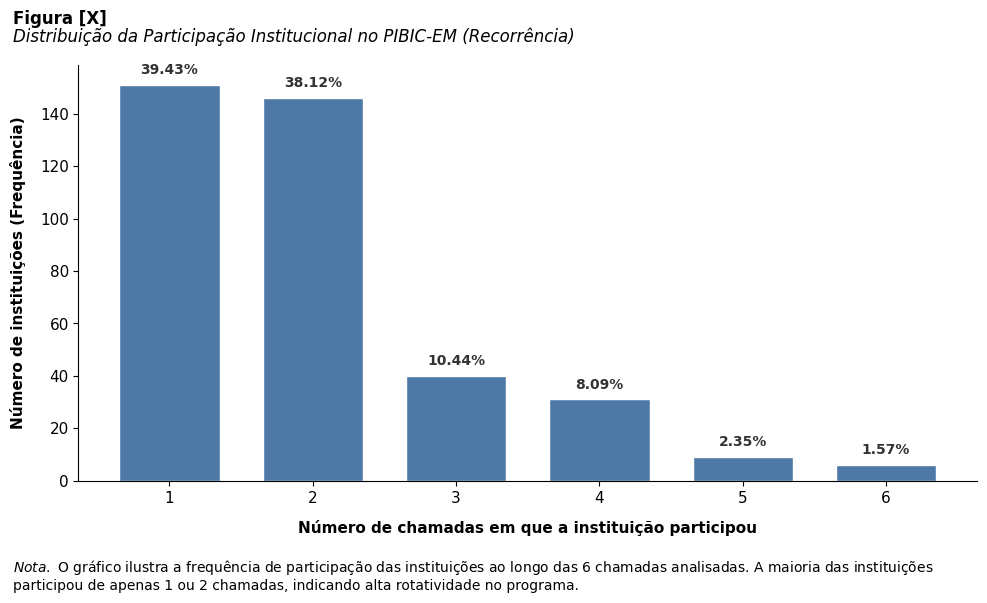

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# =========================
# 1. CONFIGURAÇÃO ESTÉTICA
# =========================
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['font.size'] = 11
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['legend.frameon'] = False

# =========================
# 2. DADOS
# =========================
dist_participacao = pd.DataFrame({
    "num_chamadas_participou": [1, 2, 3, 4, 5, 6],
    "num_instituicoes": [151, 146, 40, 31, 9, 6],
    "percentual": [39.43, 38.12, 10.44, 8.09, 2.35, 1.57]
})

# =========================
# 3. PLOTAGEM
# =========================
def plot_participation_style():
    fig, ax = plt.subplots(figsize=(10, 6))

    # Gráfico de Barras com cor sóbria (Azul Profissional)
    ax.bar(
        dist_participacao["num_chamadas_participou"],
        dist_participacao["num_instituicoes"],
        color='#4e79a7',  # Azul padrão de visualização de dados (Tableau)
        edgecolor='white',
        width=0.7
    )

    # Rótulos Percentuais
    for i, row in dist_participacao.iterrows():
        ax.text(
            row["num_chamadas_participou"],
            row["num_instituicoes"] + 3,  # Pequeno offset vertical
            f'{row["percentual"]}%',
            ha='center',
            va='bottom',
            fontsize=10,
            weight='bold',
            color='#333'
        )

    # Eixos e Títulos
    ax.set_xlabel("Número de chamadas em que a instituição participou", fontsize=11, weight='bold', labelpad=10)
    ax.set_ylabel("Número de instituições (Frequência)", fontsize=11, weight='bold', labelpad=10)
    ax.set_xticks(dist_participacao["num_chamadas_participou"])

    # Cabeçalho APA (Título Interno)
    fig.text(0.02, 0.96, "Figura [X]", fontsize=12, weight='bold') # Substitua [X] pelo número correto
    fig.text(0.02, 0.93, "Distribuição da Participação Institucional no PIBIC-EM (Recorrência)", fontsize=12, style='italic')

    # Nota de Rodapé
    note = (r"$\it{Nota.}$ O gráfico ilustra a frequência de participação das instituições ao longo das 6 chamadas analisadas. "
            "A maioria das instituições participou de apenas 1 ou 2 chamadas, indicando alta rotatividade no programa.")
    fig.text(0.02, 0.02, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0.08, 1, 0.92])
    plt.savefig("distribuicao_participacao_apa.png", dpi=300, bbox_inches='tight')
    plt.show()

plot_participation_style()

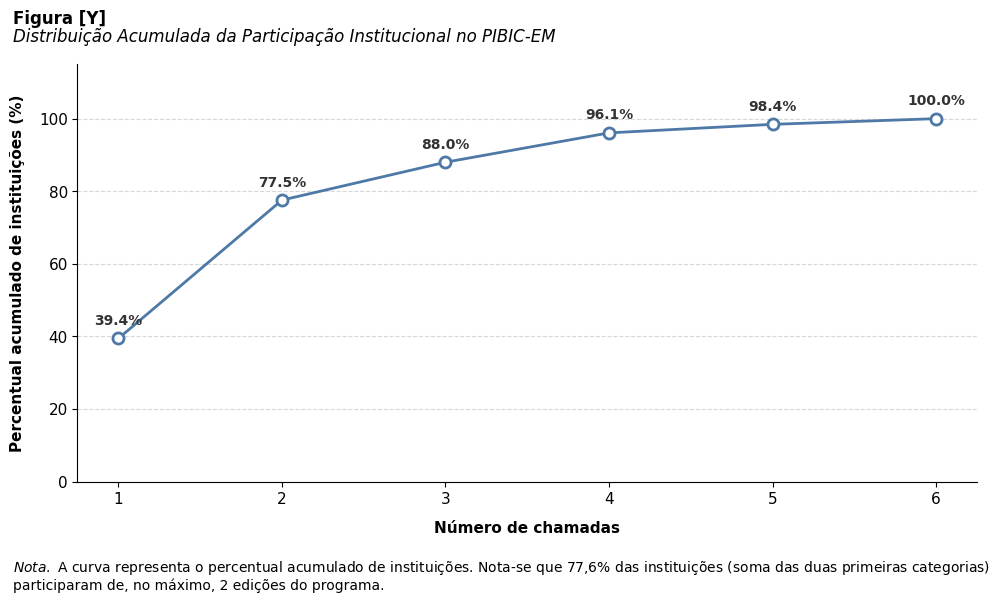

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# =========================
# 1. CONFIGURAÇÃO ESTÉTICA
# =========================
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['font.size'] = 11
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['legend.frameon'] = False

# =========================
# 2. DADOS E CÁLCULO
# =========================
dist_participacao = pd.DataFrame({
    "num_chamadas_participou": [1, 2, 3, 4, 5, 6],
    "num_instituicoes": [151, 146, 40, 31, 9, 6],
    "percentual": [39.43, 38.12, 10.44, 8.09, 2.35, 1.57]
})

# Cálculo do acumulado
dist_participacao["percentual_acumulado"] = dist_participacao["percentual"].cumsum()

# =========================
# 3. PLOTAGEM
# =========================
def plot_cumulative_style():
    fig, ax = plt.subplots(figsize=(10, 6))

    # Linha com marcadores
    ax.plot(
        dist_participacao["num_chamadas_participou"],
        dist_participacao["percentual_acumulado"],
        marker='o',
        color='#4e79a7',      # Azul profissional
        linewidth=2,
        markersize=8,
        markerfacecolor='white', # Marcador "vazado" para leveza
        markeredgewidth=2
    )

    # Grid horizontal suave (ajuda a ler o nível acumulado)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Rótulos de Dados
    for i, row in dist_participacao.iterrows():
        ax.text(
            row["num_chamadas_participou"],
            row["percentual_acumulado"] + 3,  # Offset acima do ponto
            f'{row["percentual_acumulado"]:.1f}%',
            ha='center',
            va='bottom',
            fontsize=10,
            weight='bold',
            color='#333'
        )

    # Ajustes de Eixo
    ax.set_ylim(0, 115)  # Margem superior para os rótulos
    ax.set_xlabel("Número de chamadas", fontsize=11, weight='bold', labelpad=10)
    ax.set_ylabel("Percentual acumulado de instituições (%)", fontsize=11, weight='bold', labelpad=10)
    ax.set_xticks(dist_participacao["num_chamadas_participou"])

    # Cabeçalho APA
    fig.text(0.02, 0.96, "Figura [Y]", fontsize=12, weight='bold')
    fig.text(0.02, 0.93, "Distribuição Acumulada da Participação Institucional no PIBIC-EM", fontsize=12, style='italic')

    # Nota de Rodapé
    note = (r"$\it{Nota.}$ A curva representa o percentual acumulado de instituições. "
            "Nota-se que 77,6% das instituições (soma das duas primeiras categorias) participaram de, no máximo, 2 edições do programa.")
    fig.text(0.02, 0.02, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0.08, 1, 0.92])
    plt.savefig("distribuicao_acumulada_apa.png", dpi=300, bbox_inches='tight')
    plt.show()

plot_cumulative_style()


# **ANÁLISE 2 — Distribuição da participação por chamadas e por região**


A recorrência institucional se distribui de forma homogênea entre as regiões?

##Variáveis
* num_chamadas_participou
* regiao_corrigida

##Procedimento

* Tabela de contingência (região × nº de participação)
* Percentuais por linha ou coluna

##Produto

* Tabela
* Heatmap ou gráfico empilhado

##Objetivo interpretativo

* Identificar regiões com:
maior rotatividade institucional E
maior concentração de instituições recorrentes

#Registro

Tipo: Descritiva bivariada
Técnica: Crosstab + percentuais

In [30]:
import pandas as pd

# =========================
# DADOS
# =========================
arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
df = pd.read_csv(arquivo, low_memory=False)

COL_INST = "inst_padronizada"
COL_PART = "num_chamadas_participou"
COL_REG  = "regiao_corrigida"

# limpeza mínima
df[COL_INST] = df[COL_INST].astype("string").str.strip()
df[COL_REG]  = df[COL_REG].astype("string").str.strip()
df[COL_PART] = pd.to_numeric(df[COL_PART], errors="coerce")

df = df.dropna(subset=[COL_INST, COL_PART, COL_REG])
df[COL_PART] = df[COL_PART].astype(int)

# garante 1 linha por instituição
df_inst = df[[COL_INST, COL_PART, COL_REG]].drop_duplicates()

# =========================
# TABELA DE CONTINGÊNCIA
# =========================
tab_regiao_part = (
    pd.crosstab(
        df_inst[COL_REG],
        df_inst[COL_PART],
        margins=True
    )
)

tab_regiao_part


num_chamadas_participou,1,2,3,4,5,6,All
regiao_corrigida,,,,,,,
Centro-Oeste,16,13,1,1,1,0,32
Nordeste,32,31,12,7,1,1,84
Norte,18,13,5,1,1,0,38
Sudeste,54,54,10,11,3,3,135
Sul,32,36,12,11,3,2,96
All,152,147,40,31,9,6,385


In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# TABELA DE CONTINGÊNCIA
# =========================
data = {
    "regiao_corrigida": ["Centro-Oeste", "Nordeste", "Norte", "Sudeste", "Sul"],
    1: [16, 32, 18, 54, 32],
    2: [13, 31, 13, 54, 36],
    3: [1, 12, 5, 10, 12],
    4: [1, 7, 1, 11, 11],
    5: [1, 1, 1, 3, 3],
    6: [0, 1, 0, 3, 2],
}

df = pd.DataFrame(data).set_index("regiao_corrigida")

# =========================
# CONVERSÃO PARA PERCENTUAL
# =========================
df_pct = df.div(df.sum(axis=1), axis=0) * 100
df_pct = df_pct.round(2)

df_pct


,1,2,3,4,5,6
regiao_corrigida,,,,,,
Centro-Oeste,50.00,40.62,3.12,3.12,3.12,0.00
Nordeste,38.10,36.90,14.29,8.33,1.19,1.19
Norte,47.37,34.21,13.16,2.63,2.63,0.00
Sudeste,40.00,40.00,7.41,8.15,2.22,2.22
Sul,33.33,37.50,12.50,11.46,3.12,2.08


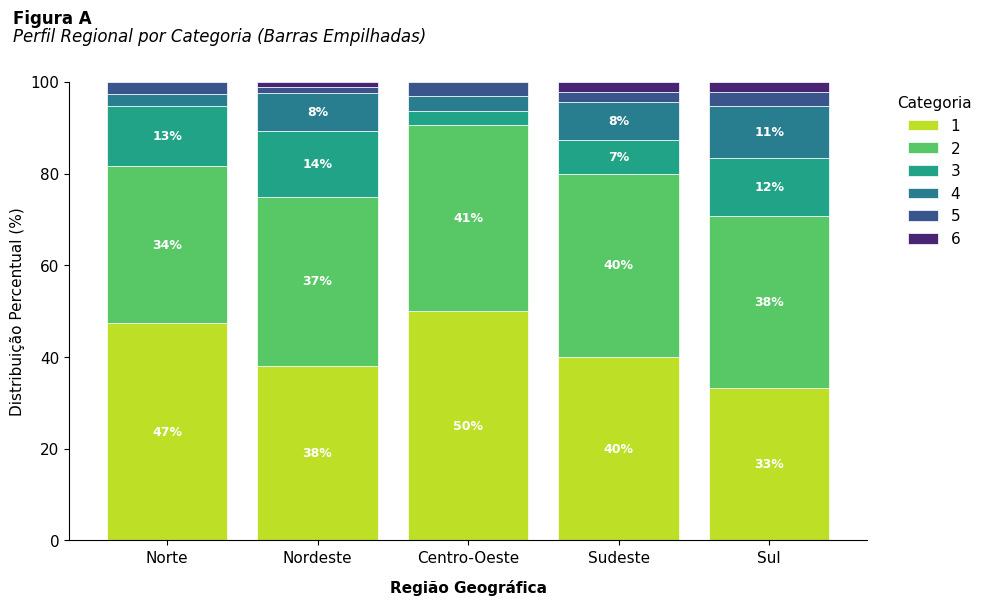

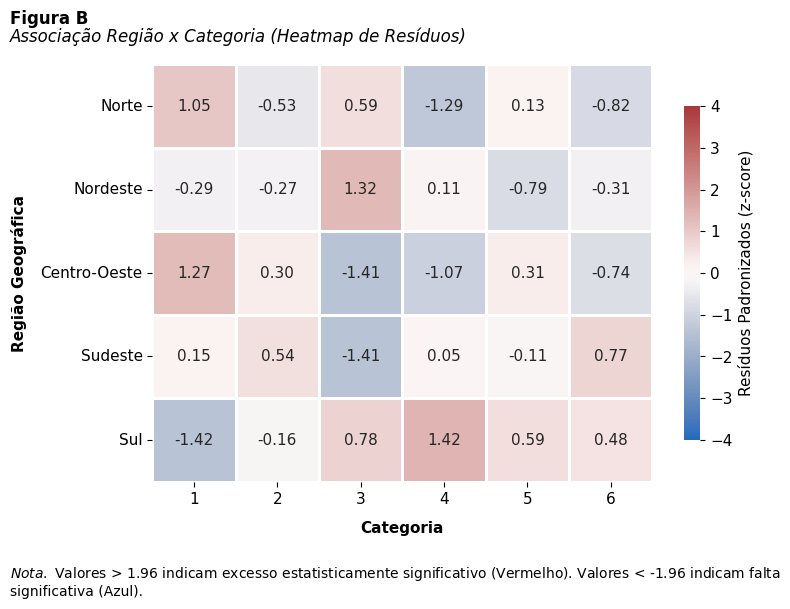

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from matplotlib import rcParams

# ==============================================================================
# 1. CONFIGURAÇÃO ESTÉTICA (APA 7)
# ==============================================================================
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['font.size'] = 11
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['legend.frameon'] = False

# ==============================================================================
# 2. DADOS FORNECIDOS
# ==============================================================================
data = {
    "regiao_corrigida": ["Centro-Oeste", "Nordeste", "Norte", "Sudeste", "Sul"],
    1: [16, 32, 18, 54, 32],
    2: [13, 31, 13, 54, 36],
    3: [1, 12, 5, 10, 12],
    4: [1, 7, 1, 11, 11],
    5: [1, 1, 1, 3, 3],
    6: [0, 1, 0, 3, 2],
}

df = pd.DataFrame(data).set_index("regiao_corrigida")

# Se quiser renomear as colunas para a legenda, altere aqui:
# df.columns = ['Conceito 1', 'Conceito 2', 'Conceito 3', 'Conceito 4', 'Conceito 5', 'Conceito 6']

# ==============================================================================
# 3. VISUALIZAÇÃO 1: BARRAS EMPILHADAS (Percentuais)
# ==============================================================================
def plot_stacked_bar():
    # Cálculo dos percentuais
    df_pct = df.div(df.sum(axis=1), axis=0) * 100

    # Ordenação Geográfica Lógica
    ordem_reg = ['Norte', 'Nordeste', 'Centro-Oeste', 'Sudeste', 'Sul']
    df_pct = df_pct.reindex(ordem_reg)

    # Paleta de Cores (Sequencial, pois 1->6 sugere ordem)
    # Use 'viridis_r', 'Blues', ou 'YlGnBu'
    cmap = plt.get_cmap('viridis_r')
    colors = [cmap(i) for i in np.linspace(0.1, 0.9, len(df.columns))]

    fig, ax = plt.subplots(figsize=(10, 6))

    df_pct.plot(kind='bar', stacked=True, width=0.8, color=colors, ax=ax, edgecolor='white', linewidth=0.5)

    # Rótulos de Dados (Apenas se > 4% para limpeza)
    for c in ax.containers:
        labels = [f'{v.get_height():.0f}%' if v.get_height() > 4 else '' for v in c]
        ax.bar_label(c, labels=labels, label_type='center', fontsize=9, color='white', weight='bold')

    ax.set_xlabel("Região Geográfica", weight='bold', fontsize=11, labelpad=10)
    ax.set_ylabel("Distribuição Percentual (%)", fontsize=11)
    ax.set_ylim(0, 100)
    plt.xticks(rotation=0, ha='center')

    # Legenda Externa
    ax.legend(title="Categoria", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

    fig.text(0.02, 0.98, "Figura A", fontsize=12, weight='bold')
    fig.text(0.02, 0.95, "Perfil Regional por Categoria (Barras Empilhadas)", fontsize=12, style='italic')

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.savefig("stacked_bar_custom.png", dpi=300, bbox_inches='tight')
    plt.show()

# ==============================================================================
# 4. VISUALIZAÇÃO 2: HEATMAP DE RESÍDUOS
# ==============================================================================
def plot_heatmap_residuals():
    # Cálculo manual dos resíduos ajustados a partir da tabela bruta
    observed = df.values
    chi2, p, dof, expected = chi2_contingency(observed)

    with np.errstate(divide='ignore', invalid='ignore'):
        n = observed.sum()
        row_p = observed.sum(axis=1) / n
        col_p = observed.sum(axis=0) / n
        div = np.sqrt(expected * (1 - row_p[:, np.newaxis]) * (1 - col_p[np.newaxis, :]))
        adj_res = (observed - expected) / div

    df_res = pd.DataFrame(adj_res, index=df.index, columns=df.columns).fillna(0)

    # Ordenação
    ordem_reg = ['Norte', 'Nordeste', 'Centro-Oeste', 'Sudeste', 'Sul']
    df_res = df_res.reindex(ordem_reg)

    fig, ax = plt.subplots(figsize=(8, 6))

    # Heatmap Divergente (-4 a +4 para contraste)
    sns.heatmap(df_res, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-4, vmax=4,
                linewidths=1, linecolor='white', cbar_kws={'label': 'Resíduos Padronizados (z-score)', 'shrink': 0.8}, ax=ax)

    ax.set_ylabel("Região Geográfica", weight='bold', fontsize=11, labelpad=10)
    ax.set_xlabel("Categoria", weight='bold', fontsize=11, labelpad=10)
    plt.yticks(rotation=0)

    fig.text(0.02, 0.96, "Figura B", fontsize=12, weight='bold')
    fig.text(0.02, 0.93, "Associação Região x Categoria (Heatmap de Resíduos)", fontsize=12, style='italic')

    note = (r"$\it{Nota.}$ Valores > 1.96 indicam excesso estatisticamente significativo (Vermelho). "
            "Valores < -1.96 indicam falta significativa (Azul).")
    fig.text(0.02, 0.01, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0.08, 1, 0.92])
    plt.savefig("heatmap_residuals_custom.png", dpi=300, bbox_inches='tight')
    plt.show()

# Executar
plot_stacked_bar()
plot_heatmap_residuals()

In [31]:
# percentual por linha (região)
tab_regiao_pct = (
    tab_regiao_part
    .div(tab_regiao_part.loc[:, tab_regiao_part.columns != "All"].sum(axis=1), axis=0)
    * 100
).round(2)

tab_regiao_pct


num_chamadas_participou,1,2,3,4,5,6,All
regiao_corrigida,,,,,,,
Centro-Oeste,50.00,40.62,3.12,3.12,3.12,0.00,100.0
Nordeste,38.10,36.90,14.29,8.33,1.19,1.19,100.0
Norte,47.37,34.21,13.16,2.63,2.63,0.00,100.0
Sudeste,40.00,40.00,7.41,8.15,2.22,2.22,100.0
Sul,33.33,37.50,12.50,11.46,3.12,2.08,100.0
All,39.48,38.18,10.39,8.05,2.34,1.56,100.0


# **ANÁLISE 3 — Instituições com maior número absoluto de proponentes**

##Pergunta
Quais instituições concentram o maior número de proponentes selecionados?

##Variáveis

*inst_padronizada
*identificador de proponente (ou contagem de linhas)

##Procedimento

* Ranking de instituições por número total de proponentes
TOP 10 / TOP 20 / TOP 50

##Produto

* Tabela ordenada
* Gráfico de barras horizontais

##Objetivo interpretativo

* Identificar concentração institucional
* Evidenciar “instituições centrais” no funcionamento do programa

##Registro

* Tipo: Descritiva univariada
* Técnica: Ranking e distribuição acumulada

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# DADOS
# =========================
arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
df = pd.read_csv(arquivo, low_memory=False)

COL_INST = "inst_padronizada"

df[COL_INST] = df[COL_INST].astype("string").str.strip()
df = df.dropna(subset=[COL_INST])

# =========================
# RANKING NACIONAL
# =========================
ranking_inst = (
    df[COL_INST]
    .value_counts()
    .reset_index()
)

ranking_inst.columns = ["instituicao", "num_proponentes"]

TOP_N = 15
ranking_top = ranking_inst.head(TOP_N)

ranking_top


,instituicao,num_proponentes
0,INSTITUTO FEDERAL DE EDUCACAO CIENCIA E TECNOL...,7
1,UNIVERSIDADE ESTADUAL DE MONTES CLAROS,7
2,UNIVERSIDADE FEDERAL DO AMAZONAS,7
3,INSTITUTO FEDERAL DE EDUCACAO CIENCIA E TECNOL...,6
4,INSTITUTO FEDERAL DE EDUCACAO CIENCIA E TECNOL...,6
5,UNIVERSIDADE FEDERAL DE UBERLANDIA,6
6,INSTITUTO FEDERAL DE EDUCACAO CIENCIA E TECNOL...,5
7,UNIVERSIDADE FEDERAL DO MARANHAO,5
8,UNIVERSIDADE FEDERAL DE CAMPINA GRANDE,5
9,UNIVERSIDADE REGIONAL DO NOROESTE DO ESTADO DO...,5


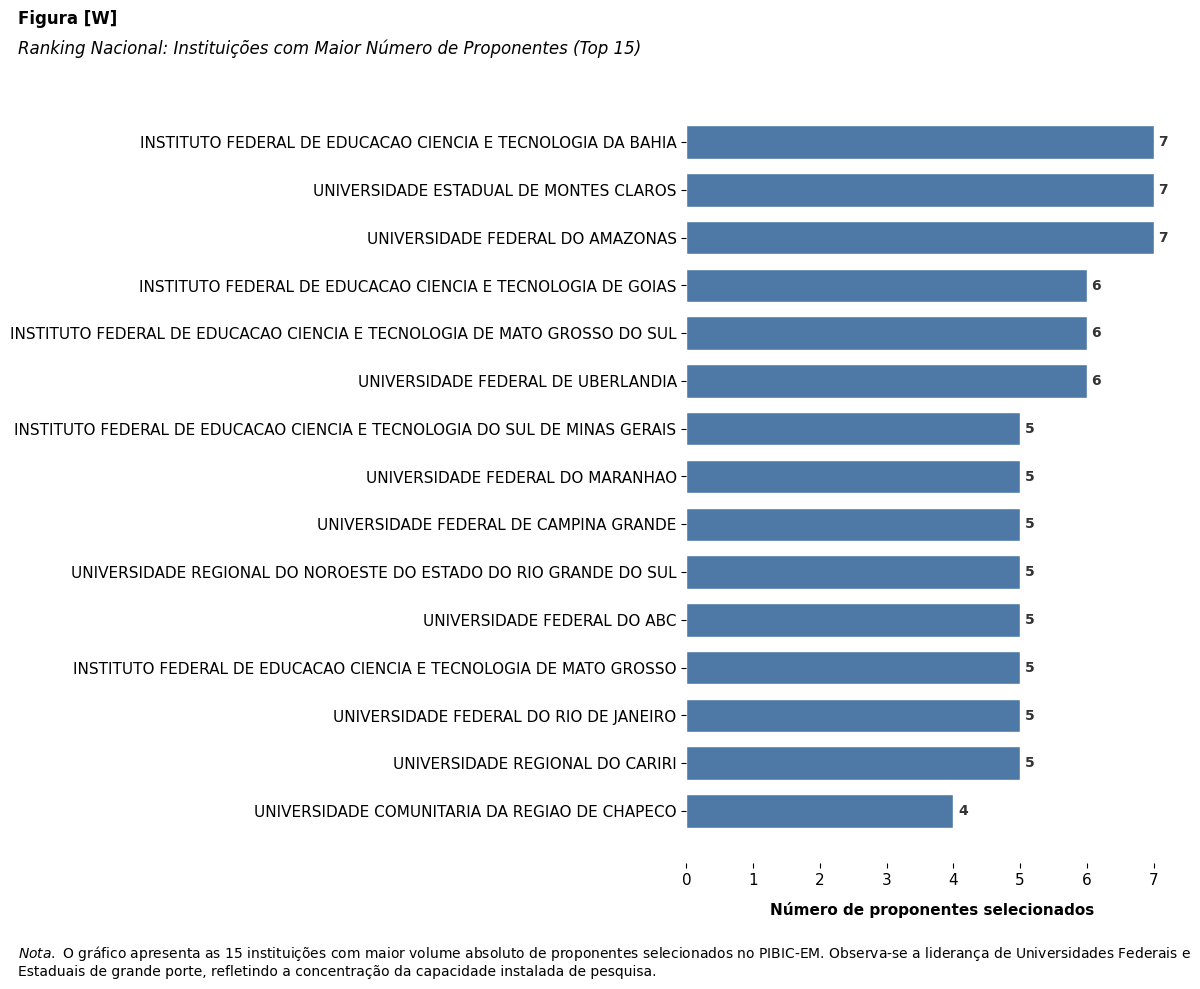

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ==============================================================================
# 1. CONFIGURAÇÃO ESTÉTICA (PADRÃO DO PROJETO)
# ==============================================================================
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['font.size'] = 11
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.spines.left'] = False # Remove eixo Y (nomes ficam "flutuando" ou alinhados)
rcParams['axes.spines.bottom'] = False # Remove linha inferior (opcional, mas limpa bem)
rcParams['legend.frameon'] = False

# ==============================================================================
# 2. DADOS (CÓDIGO DO USUÁRIO)
# ==============================================================================
arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"

try:
    df = pd.read_csv(arquivo, low_memory=False)

    COL_INST = "inst_padronizada"

    # Limpeza e Tipagem
    df[COL_INST] = df[COL_INST].astype("string").str.strip()
    df = df.dropna(subset=[COL_INST])

    # Ranking Nacional
    ranking_inst = (
        df[COL_INST]
        .value_counts()
        .reset_index()
    )
    ranking_inst.columns = ["instituicao", "num_proponentes"]

    TOP_N = 15
    ranking_top = ranking_inst.head(TOP_N)

except Exception as e:
    print(f"Erro ao processar dados: {e}")
    # Dados de exemplo caso o arquivo não esteja disponível na sessão
    ranking_top = pd.DataFrame({
        "instituicao": [f"Instituição {i}" for i in range(1, 16)],
        "num_proponentes": range(150, 0, -10)
    })
    TOP_N = 15

# ==============================================================================
# 3. PLOTAGEM (VISUALIZAÇÃO ESTILIZADA)
# ==============================================================================
def plot_ranking_top15():
    # Aumentar altura da figura para acomodar 15 barras confortavelmente
    fig, ax = plt.subplots(figsize=(12, 10))

    # Plotagem (Invertendo ordem [::-1] para o 1º ficar no topo)
    bars = ax.barh(
        ranking_top["instituicao"][::-1],
        ranking_top["num_proponentes"][::-1],
        color='#4e79a7',  # Azul Profissional
        height=0.7,       # Altura da barra (espessura)
        edgecolor='white'
    )

    # Rótulos de Dados (Números ao lado da barra)
    max_val = ranking_top["num_proponentes"].max()
    offset = max_val * 0.01 # Pequeno deslocamento proporcional

    for i, v in enumerate(ranking_top["num_proponentes"][::-1]):
        ax.text(
            v + offset,
            i,
            str(v),
            va='center',
            fontsize=10,
            weight='bold',
            color='#333'
        )

    # Ajustes de Eixo
    ax.set_xlabel("Número de proponentes selecionados", fontsize=11, weight='bold', labelpad=10)
    # Removemos label Y "Instituição" pois os nomes já são autoexplicativos

    # Títulos Internos (Estilo APA)
    fig.text(0.02, 0.97, "Figura [W]", fontsize=12, weight='bold')
    fig.text(0.02, 0.94, f"Ranking Nacional: Instituições com Maior Número de Proponentes (Top {TOP_N})", fontsize=12, style='italic')

    # Nota de Rodapé
    note = (r"$\it{Nota.}$ O gráfico apresenta as 15 instituições com maior volume absoluto de proponentes selecionados no PIBIC-EM. "
            "Observa-se a liderança de Universidades Federais e Estaduais de grande porte, refletindo a concentração da capacidade instalada de pesquisa.")
    fig.text(0.02, 0.02, note, fontsize=10, ha='left', wrap=True)

    # Ajuste fino de layout para nomes longos não cortarem
    plt.tight_layout(rect=[0, 0.06, 1, 0.92])
    plt.savefig("ranking_top15_apa.png", dpi=300, bbox_inches='tight')
    plt.show()

plot_ranking_top15()

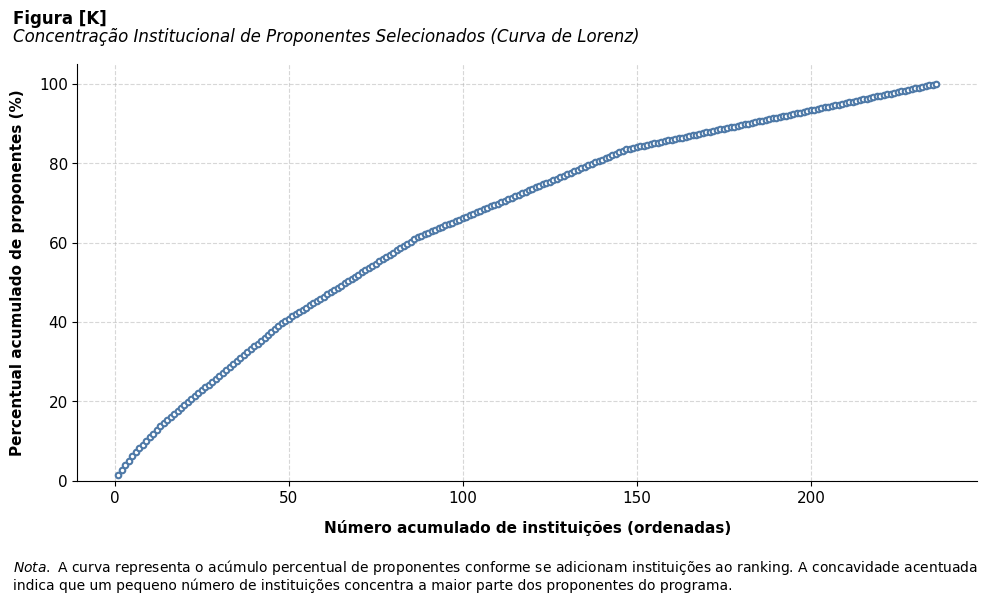

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ==============================================================================
# 1. CONFIGURAÇÃO ESTÉTICA (APA)
# ==============================================================================
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['font.size'] = 11
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.spines.left'] = True
rcParams['axes.spines.bottom'] = True
rcParams['legend.frameon'] = False

# ==============================================================================
# 2. PROCESSAMENTO DE DADOS (SEU CÓDIGO)
# ==============================================================================
arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"

try:
    df = pd.read_csv(arquivo, low_memory=False)
    COL_INST = "inst_padronizada"

    # Limpeza
    df[COL_INST] = df[COL_INST].astype("string").str.strip()
    df = df.dropna(subset=[COL_INST])

    # Ranking e Percentuais
    ranking_inst = df[COL_INST].value_counts().reset_index()
    ranking_inst.columns = ["instituicao", "num_proponentes"]

    ranking_inst["percentual"] = (
        ranking_inst["num_proponentes"]
        / ranking_inst["num_proponentes"].sum()
        * 100
    )
    ranking_inst["percentual_acumulado"] = ranking_inst["percentual"].cumsum()

except Exception as e:
    print(f"Erro ao carregar dados: {e}")
    # Mock para garantir funcionamento do exemplo
    ranking_inst = pd.DataFrame({"num_proponentes": range(100, 0, -1)})
    ranking_inst["percentual"] = ranking_inst["num_proponentes"] / ranking_inst["num_proponentes"].sum() * 100
    ranking_inst["percentual_acumulado"] = ranking_inst["percentual"].cumsum()

# ==============================================================================
# 3. PLOTAGEM ESTILIZADA
# ==============================================================================
def plot_concentration_style():
    fig, ax = plt.subplots(figsize=(10, 6))

    # Ajuste dinâmico do marcador para evitar poluição visual se N for grande
    marker_size = 4 if len(ranking_inst) > 50 else 6

    # Curva de Concentração
    ax.plot(
        range(1, len(ranking_inst) + 1),
        ranking_inst["percentual_acumulado"],
        marker='o',
        color='#4e79a7',         # Azul Profissional
        linewidth=2,
        markersize=marker_size,
        markerfacecolor='white', # Marcador "leve"
        markeredgewidth=1.5
    )

    # Grid Suave
    ax.grid(True, linestyle='--', alpha=0.5)

    # Eixos
    ax.set_xlabel("Número acumulado de instituições (ordenadas)", fontsize=11, weight='bold', labelpad=10)
    ax.set_ylabel("Percentual acumulado de proponentes (%)", fontsize=11, weight='bold', labelpad=10)
    ax.set_ylim(0, 105) # Margem superior

    # Título Interno (APA)
    fig.text(0.02, 0.96, "Figura [K]", fontsize=12, weight='bold')
    fig.text(0.02, 0.93, "Concentração Institucional de Proponentes Selecionados (Curva de Lorenz)", fontsize=12, style='italic')

    # Nota de Rodapé
    note = (r"$\it{Nota.}$ A curva representa o acúmulo percentual de proponentes conforme se adicionam instituições ao ranking. "
            "A concavidade acentuada indica que um pequeno número de instituições concentra a maior parte dos proponentes do programa.")
    fig.text(0.02, 0.02, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0.08, 1, 0.92])
    plt.savefig("concentracao_institucional_apa.png", dpi=300, bbox_inches='tight')
    plt.show()

plot_concentration_style()

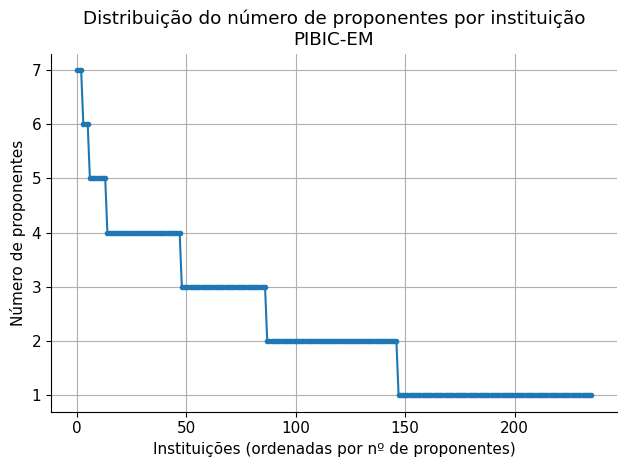

In [12]:
plt.figure()
plt.plot(
    ranking_inst["num_proponentes"].values,
    marker='.'
)

plt.xlabel("Instituições (ordenadas por nº de proponentes)")
plt.ylabel("Número de proponentes")
plt.title(
    "Distribuição do número de proponentes por instituição\n"
    "PIBIC-EM"
)

plt.grid(True)
plt.tight_layout()
plt.show()


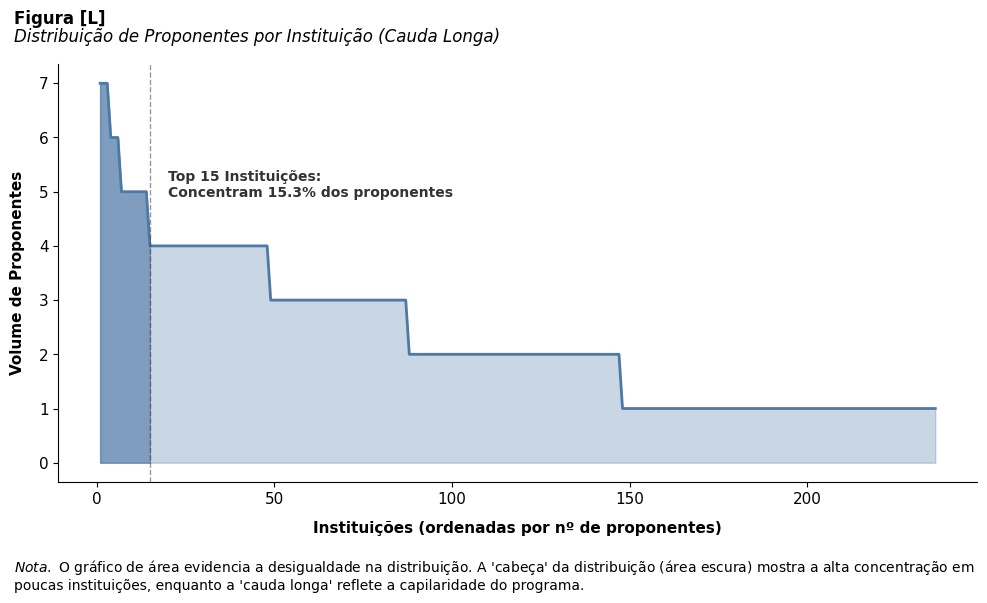

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ==============================================================================
# 1. CONFIGURAÇÃO ESTÉTICA
# ==============================================================================
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['font.size'] = 11
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.spines.left'] = True
rcParams['axes.spines.bottom'] = True
rcParams['legend.frameon'] = False

# ==============================================================================
# 2. DADOS (SEU CÓDIGO)
# ==============================================================================
arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"

try:
    df = pd.read_csv(arquivo, low_memory=False)
    COL_INST = "inst_padronizada"
    df[COL_INST] = df[COL_INST].astype("string").str.strip()
    df = df.dropna(subset=[COL_INST])

    ranking_inst = df[COL_INST].value_counts().reset_index()
    ranking_inst.columns = ["instituicao", "num_proponentes"]

except Exception as e:
    print(f"Erro nos dados: {e}")
    # Mock para teste
    ranking_inst = pd.DataFrame({
        "instituicao": [f"I{i}" for i in range(200)],
        "num_proponentes": [int(150/(1+0.05*i)) for i in range(200)]
    })

# ==============================================================================
# 3. PLOTAGEM ESTILIZADA (CAUDA LONGA)
# ==============================================================================
def plot_long_tail_style():
    fig, ax = plt.subplots(figsize=(10, 6))

    # Eixo X (Ranking) e Y (Volume)
    x = range(1, len(ranking_inst) + 1)
    y = ranking_inst["num_proponentes"]

    # Gráfico de Área (Elegante)
    ax.fill_between(x, y, color='#4e79a7', alpha=0.3)
    ax.plot(x, y, color='#4e79a7', linewidth=2)

    # Destaque para o "Head" (Top 15)
    top_n = 15
    ax.fill_between(x[:top_n], y[:top_n], color='#4e79a7', alpha=0.6) # Mais escuro
    ax.axvline(x=top_n, color='#333', linestyle='--', linewidth=1, alpha=0.5)

    # Cálculo da Concentração para Anotação
    top_vol = y[:top_n].sum()
    total_vol = y.sum()
    pct_conc = (top_vol / total_vol) * 100

    # Anotação de Texto (Inteligente)
    ax.text(
        top_n + 5,
        y.max() * 0.7,
        f"Top {top_n} Instituições:\nConcentram {pct_conc:.1f}% dos proponentes",
        fontsize=10,
        weight='bold',
        color='#333',
        ha='left'
    )

    # Eixos e Títulos
    ax.set_xlabel("Instituições (ordenadas por nº de proponentes)", fontsize=11, weight='bold', labelpad=10)
    ax.set_ylabel("Volume de Proponentes", fontsize=11, weight='bold', labelpad=10)

    # Título Interno (APA)
    fig.text(0.02, 0.96, "Figura [L]", fontsize=12, weight='bold')
    fig.text(0.02, 0.93, "Distribuição de Proponentes por Instituição (Cauda Longa)", fontsize=12, style='italic')

    # Nota
    note = (r"$\it{Nota.}$ O gráfico de área evidencia a desigualdade na distribuição. "
            "A 'cabeça' da distribuição (área escura) mostra a alta concentração em poucas instituições, "
            "enquanto a 'cauda longa' reflete a capilaridade do programa.")
    fig.text(0.02, 0.02, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0.08, 1, 0.92])
    plt.savefig("distribuicao_cauda_longa_apa.png", dpi=300, bbox_inches='tight')
    plt.show()

plot_long_tail_style()

# **ANÁLISE 4 — Instituições com maior número de proponentes por região**

##Pergunta

As instituições dominantes são as mesmas em todas as regiões?

##Variáveis

* inst_padronizada
* regiao_corrigida

##Procedimento

* Ranking regional de instituições
* TOP N por região

##Produto

* Uma tabela por região
* Comparação cruzada entre regiões

##Objetivo interpretativo

* Evidenciar assimetrias regionais
* Relacionar com capacidade institucional instalada

#Registro

* Tipo: Descritiva estratificada
* Técnica: Ranking por estrato regional

In [16]:
import pandas as pd

# =========================
# DADOS
# =========================
arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
df = pd.read_csv(arquivo, low_memory=False)

COL_INST = "inst_padronizada"
COL_REG  = "regiao_corrigida"

df[COL_INST] = df[COL_INST].astype("string").str.strip()
df[COL_REG]  = df[COL_REG].astype("string").str.strip()

df = df.dropna(subset=[COL_INST, COL_REG])

# =========================
# RANKING POR REGIÃO
# =========================
ranking_regional = (
    df
    .groupby([COL_REG, COL_INST])
    .size()
    .reset_index(name="num_proponentes")
    .sort_values([COL_REG, "num_proponentes"], ascending=[True, False])
)

ranking_regional


,regiao_corrigida,inst_padronizada,num_proponentes
4,Centro-Oeste,INSTITUTO FEDERAL DE EDUCACAO CIENCIA E TECNOL...,6
6,Centro-Oeste,INSTITUTO FEDERAL DE EDUCACAO CIENCIA E TECNOL...,6
5,Centro-Oeste,INSTITUTO FEDERAL DE EDUCACAO CIENCIA E TECNOL...,5
16,Centro-Oeste,UNIVERSIDADE FEDERAL DE MATO GROSSO DO SUL,4
9,Centro-Oeste,UNIVERSIDADE CATOLICA DE BRASILIA,3
...,...,...,...
222,Sul,UNIVERSIDADE FEDERAL DE PELOTAS,1
228,Sul,UNIVERSIDADE FEDERAL DO RIO GRANDE,1
231,Sul,UNIVERSIDADE FRANCISCANA,1
235,Sul,UNIVERSIDADE PARANAENSE,1


In [17]:
TOP_N = 10

top_por_regiao = (
    ranking_regional
    .groupby(COL_REG)
    .head(TOP_N)
)

top_por_regiao


,regiao_corrigida,inst_padronizada,num_proponentes
4,Centro-Oeste,INSTITUTO FEDERAL DE EDUCACAO CIENCIA E TECNOL...,6
6,Centro-Oeste,INSTITUTO FEDERAL DE EDUCACAO CIENCIA E TECNOL...,6
5,Centro-Oeste,INSTITUTO FEDERAL DE EDUCACAO CIENCIA E TECNOL...,5
16,Centro-Oeste,UNIVERSIDADE FEDERAL DE MATO GROSSO DO SUL,4
9,Centro-Oeste,UNIVERSIDADE CATOLICA DE BRASILIA,3
11,Centro-Oeste,UNIVERSIDADE ESTADUAL DE GOIAS,3
12,Centro-Oeste,UNIVERSIDADE FEDERAL DA GRANDE DE DOURADOS,3
1,Centro-Oeste,EMPRESA BRASILEIRA DE PESQUISA AGROPECUARIA,2
3,Centro-Oeste,INSTITUTO FEDERAL DE EDUCACAO CIENCIA E TECNOL...,2
8,Centro-Oeste,UNIVERSIDADE ANHANGUERA UNIDERP,2


/tmp/ipython-input-1693844723.py:17: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


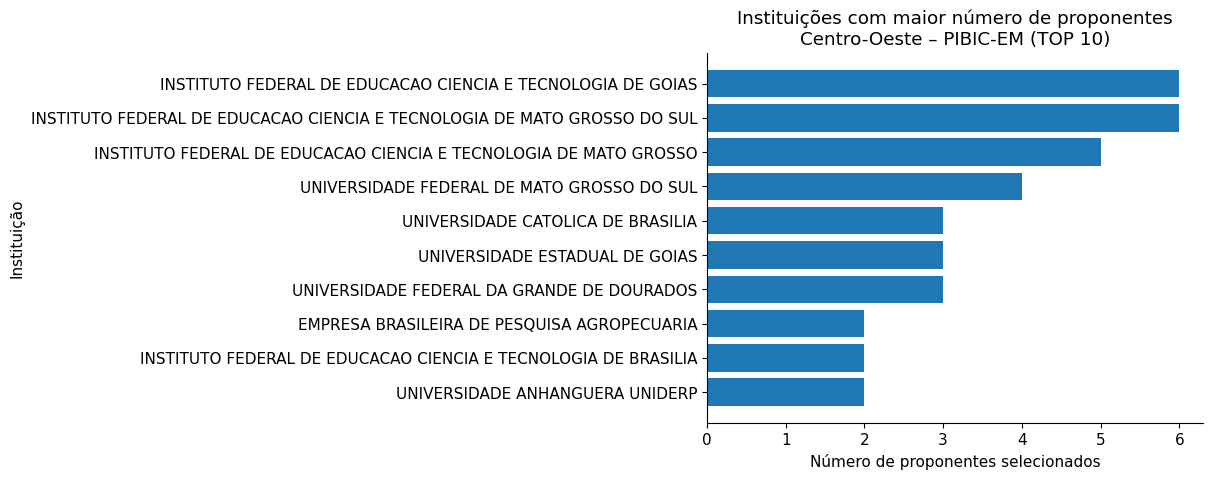

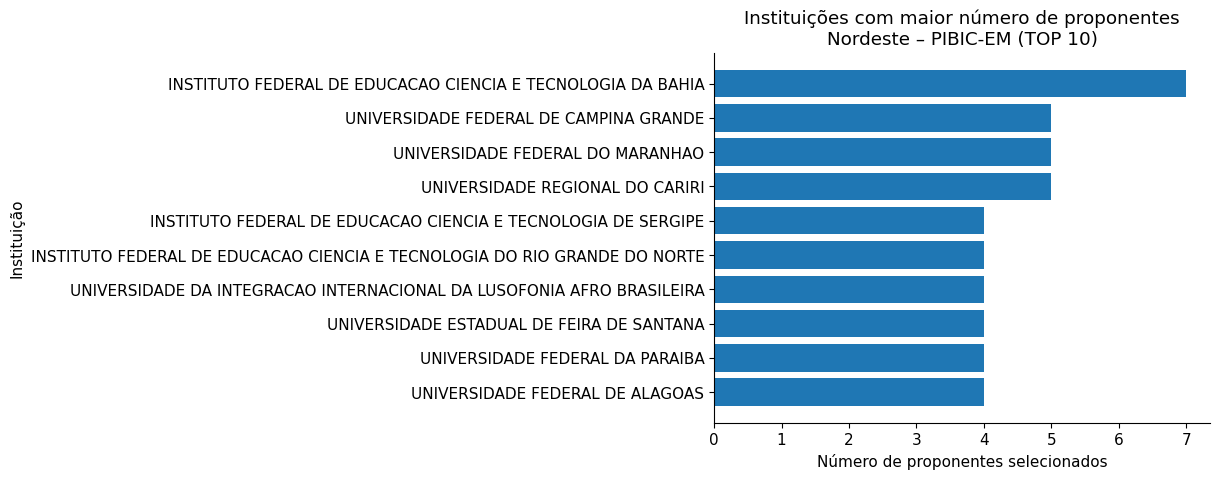

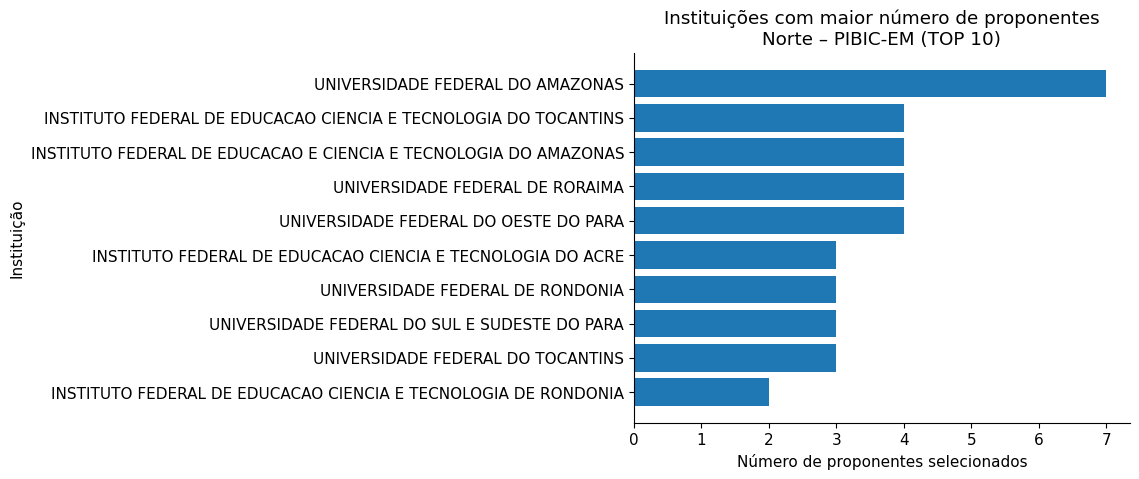

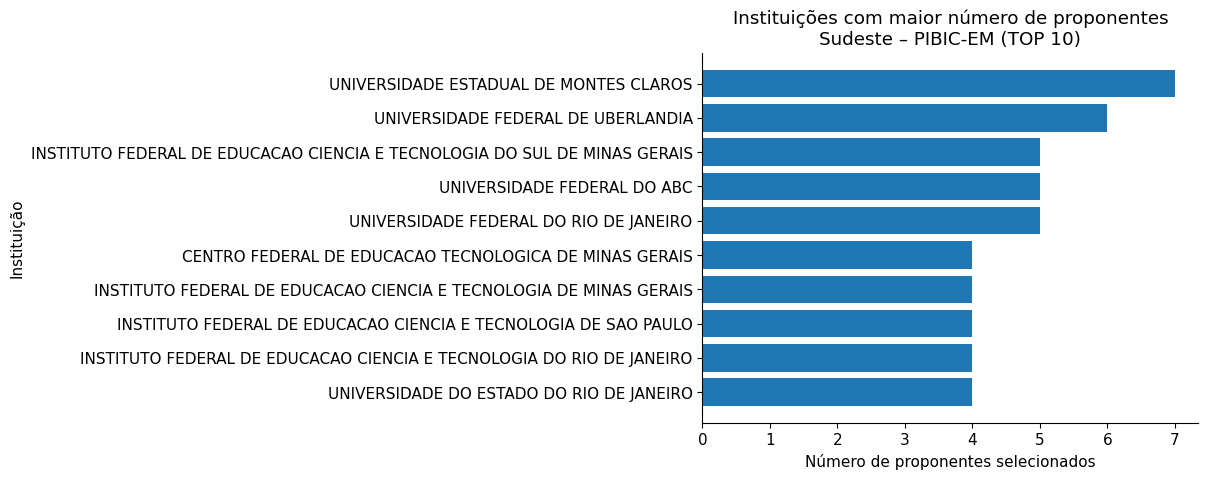

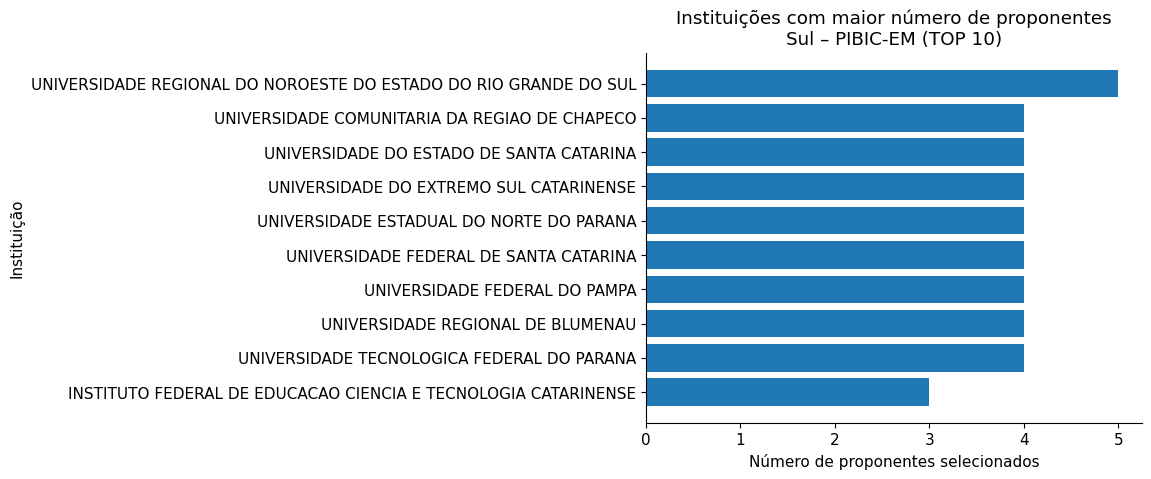

In [18]:
import matplotlib.pyplot as plt

for regiao, sub in top_por_regiao.groupby(COL_REG):
    plt.figure()
    plt.barh(
        sub[COL_INST][::-1],
        sub["num_proponentes"][::-1]
    )

    plt.xlabel("Número de proponentes selecionados")
    plt.ylabel("Instituição")
    plt.title(
        f"Instituições com maior número de proponentes\n"
        f"{regiao} – PIBIC-EM (TOP {TOP_N})"
    )

    plt.tight_layout()
    plt.show()


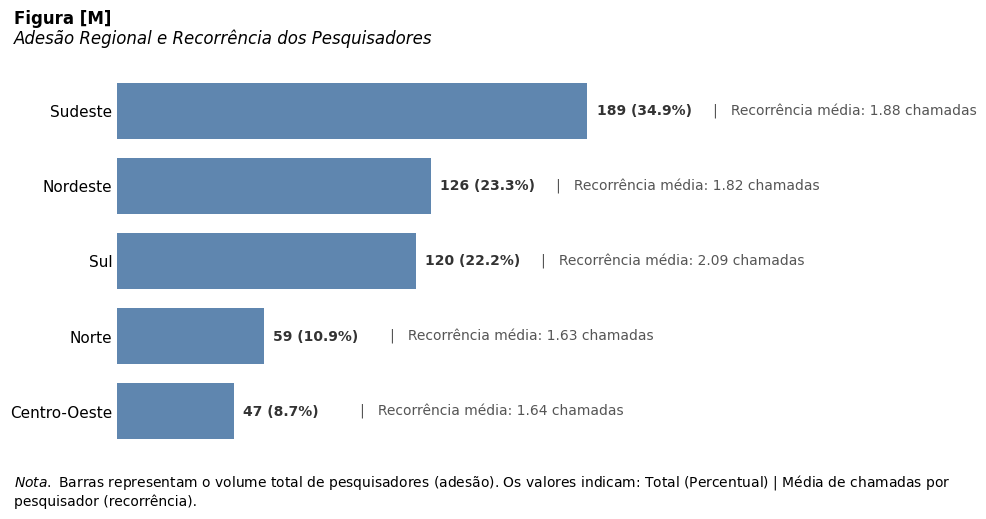

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ==============================================================================
# 1. CONFIGURAÇÃO ESTÉTICA (CLEAN / APA)
# ==============================================================================
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['font.size'] = 11
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.spines.left'] = False   # Remove linha do eixo Y
rcParams['axes.spines.bottom'] = False # Remove linha do eixo X
rcParams['legend.frameon'] = False

# ==============================================================================
# 2. PROCESSAMENTO DE DADOS
# ==============================================================================
arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"

try:
    df = pd.read_csv(arquivo, low_memory=False)
    COL_REG = "regiao_corrigida"
    COL_CHAMADAS = "num_chamadas_participou"

    # Limpeza
    df[COL_REG] = df[COL_REG].astype("string").str.strip()
    df = df.dropna(subset=[COL_REG])

    # Agregação
    regional_stats = df.groupby(COL_REG).agg(
        num_proponentes=('id_pesq', 'count'),
        media_recorrencia=(COL_CHAMADAS, 'mean')
    ).reset_index()

    # Percentual
    regional_stats['percentual'] = (regional_stats['num_proponentes'] / regional_stats['num_proponentes'].sum()) * 100

    # Ordenação
    regional_stats = regional_stats.sort_values('num_proponentes', ascending=True)

except Exception as e:
    print(f"Erro: {e}")
    # Mock fallback
    regional_stats = pd.DataFrame({
        'regiao_corrigida': ['Norte', 'Centro-Oeste', 'Sul', 'Nordeste', 'Sudeste'],
        'num_proponentes': [150, 200, 300, 450, 600],
        'media_recorrencia': [1.5, 1.8, 2.2, 2.0, 2.5],
        'percentual': [8.8, 11.7, 17.6, 26.4, 35.2]
    })

# ==============================================================================
# 3. PLOTAGEM
# ==============================================================================
def plot_regional_clean():
    # Altura reduzida para compactar o gráfico
    fig, ax = plt.subplots(figsize=(10, 5))

    # Barras mais espessas (height=0.75) para reduzir espaço em branco
    bars = ax.barh(
        regional_stats['regiao_corrigida'],
        regional_stats['num_proponentes'],
        color='#4e79a7',
        height=0.75,
        alpha=0.9
    )

    # Anotações Hierárquicas
    max_val = regional_stats['num_proponentes'].max()
    offset = max_val * 0.02

    for i, (count, pct, mean) in enumerate(zip(
        regional_stats['num_proponentes'],
        regional_stats['percentual'],
        regional_stats['media_recorrencia']
    )):
        # 1. Dado Principal (Volume) em Negrito
        main_label = f"{count} ({pct:.1f}%)"
        ax.text(
            count + offset, i, main_label,
            va='center', ha='left', fontsize=10, weight='bold', color='#333'
        )

        # 2. Dado Secundário (Fidelidade) Normal e Cinza
        # Ajuste manual do espaçamento baseado na string anterior (heurística simples)
        # O valor 0.20 é um multiplicador empírico para dar espaço após o rótulo principal
        sec_label = f"   |   Recorrência média: {mean:.2f} chamadas"
        ax.text(
            count + offset + (max_val * 0.22), i, sec_label,
            va='center', ha='left', fontsize=10, weight='normal', color='#555'
        )

    # Limpeza de Eixos
    ax.set_xticks([])
    ax.tick_params(axis='y', length=0)

    # Expandir limite X para caber textos
    ax.set_xlim(0, max_val * 1.65)

    # Títulos e Nota
    fig.text(0.02, 0.98, "Figura [M]", fontsize=12, weight='bold')
    fig.text(0.02, 0.94, "Adesão Regional e Recorrência dos Pesquisadores", fontsize=12, style='italic')

    note = (r"$\it{Nota.}$ Barras representam o volume total de pesquisadores (adesão). "
            "Os valores indicam: Total (Percentual) | Média de chamadas por pesquisador (recorrência).")
    fig.text(0.02, 0.02, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0.08, 1, 0.93])
    plt.savefig("adesao_regional_clean.png", dpi=300, bbox_inches='tight')
    plt.show()

plot_regional_clean()

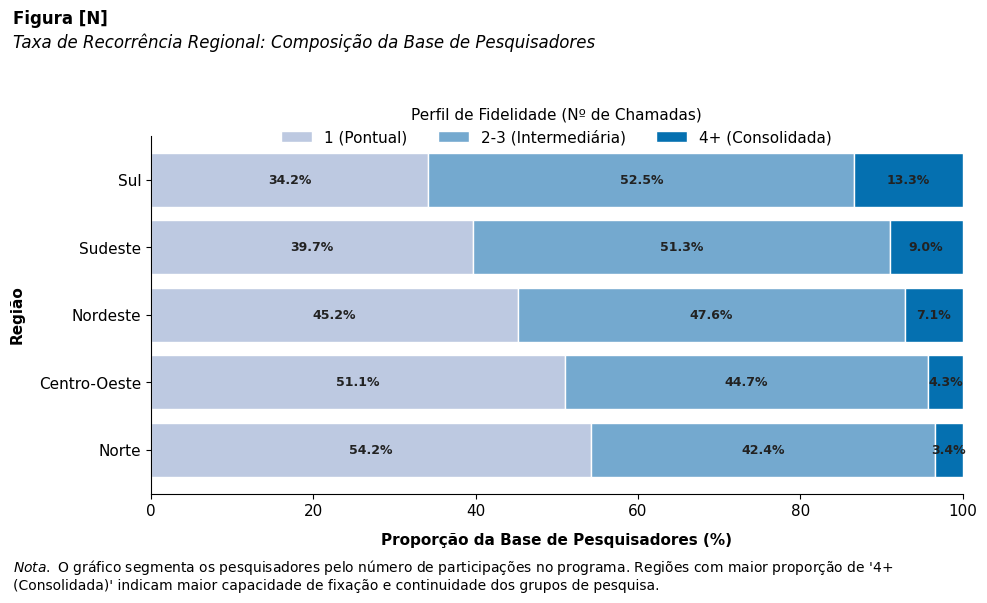

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ==============================================================================
# 1. CONFIGURAÇÃO ESTÉTICA (APA)
# ==============================================================================
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['font.size'] = 11
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.spines.left'] = True
rcParams['axes.spines.bottom'] = True
rcParams['legend.frameon'] = False

# ==============================================================================
# 2. PROCESSAMENTO DE DADOS
# ==============================================================================
arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"

try:
    df = pd.read_csv(arquivo, low_memory=False)
    COL_REG = "regiao_corrigida"
    COL_CHAMADAS = "num_chamadas_participou"

    # Limpeza
    df[COL_REG] = df[COL_REG].astype("string").str.strip()
    df = df.dropna(subset=[COL_REG, COL_CHAMADAS])

    # Categorização de Fidelidade (Clusterização Lógica)
    def categorizar_fidelidade(n):
        if n == 1: return '1 (Pontual)'
        if 2 <= n <= 3: return '2-3 (Intermediária)'
        if n >= 4: return '4+ (Consolidada)'
        return 'Outro'

    df['categoria_fidelidade'] = df[COL_CHAMADAS].apply(categorizar_fidelidade)

    # Tabela Cruzada (100% Stacked)
    ct = pd.crosstab(df[COL_REG], df['categoria_fidelidade'], normalize='index') * 100

    # Ordenação Lógica das Colunas
    cols_order = ['1 (Pontual)', '2-3 (Intermediária)', '4+ (Consolidada)']
    ct = ct[cols_order]

    # Ordenação das Linhas: Pela taxa de consolidação (quem retém mais?)
    ct = ct.sort_values('4+ (Consolidada)', ascending=True)

except Exception as e:
    print(f"Erro: {e}")
    # Mock data
    regions = ['Norte', 'Centro-Oeste', 'Sul', 'Nordeste', 'Sudeste']
    ct = pd.DataFrame({
        '1 (Pontual)': [60, 55, 40, 45, 35],
        '2-3 (Intermediária)': [30, 30, 35, 35, 40],
        '4+ (Consolidada)': [10, 15, 25, 20, 25]
    }, index=regions)

# ==============================================================================
# 3. PLOTAGEM
# ==============================================================================
def plot_recurrence_stacked():
    fig, ax = plt.subplots(figsize=(10, 6))

    # Paleta Sequencial (Azuis)
    # Claro = Pontual | Médio = Intermediário | Escuro = Consolidado
    colors = ['#bdc9e1', '#74a9cf', '#0570b0']

    # Plotagem
    ct.plot(
        kind='barh',
        stacked=True,
        color=colors,
        width=0.8,
        edgecolor='white', # Separação limpa entre segmentos
        ax=ax
    )

    # Rótulos de Dados (% dentro das barras)
    for c in ax.containers:
        # Apenas mostra rótulo se a barra for larga o suficiente (> 5%)
        labels = [f'{v.get_width():.1f}%' if v.get_width() > 3 else '' for v in c]
        # Cor preta para legibilidade nos tons claros, branca funcionaria no escuro
        # Aqui usamos um cinza muito escuro para consistência
        ax.bar_label(c, labels=labels, label_type='center', fontsize=9, color='#222', weight='bold')

    # Eixos e Legenda
    ax.set_xlabel("Proporção da Base de Pesquisadores (%)", fontsize=11, weight='bold', labelpad=10)
    ax.set_ylabel("Região", fontsize=11, weight='bold', labelpad=10)
    ax.set_xlim(0, 100)

    # Legenda no Topo
    ax.legend(
        title="Perfil de Fidelidade (Nº de Chamadas)",
        bbox_to_anchor=(0.5, 1.12),
        loc='upper center',
        ncol=3,
        frameon=False
    )

    # Título Interno (APA)
    fig.text(0.02, 0.96, "Figura [N]", fontsize=12, weight='bold')
    fig.text(0.02, 0.92, "Taxa de Recorrência Regional: Composição da Base de Pesquisadores", fontsize=12, style='italic')

    # Nota
    note = (r"$\it{Nota.}$ O gráfico segmenta os pesquisadores pelo número de participações no programa. "
            "Regiões com maior proporção de '4+ (Consolidada)' indicam maior capacidade de fixação e continuidade dos grupos de pesquisa.")
    fig.text(0.02, 0.02, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0.06, 1, 0.88])
    plt.savefig("taxa_recorrencia_regional.png", dpi=300, bbox_inches='tight')
    plt.show()

plot_recurrence_stacked()

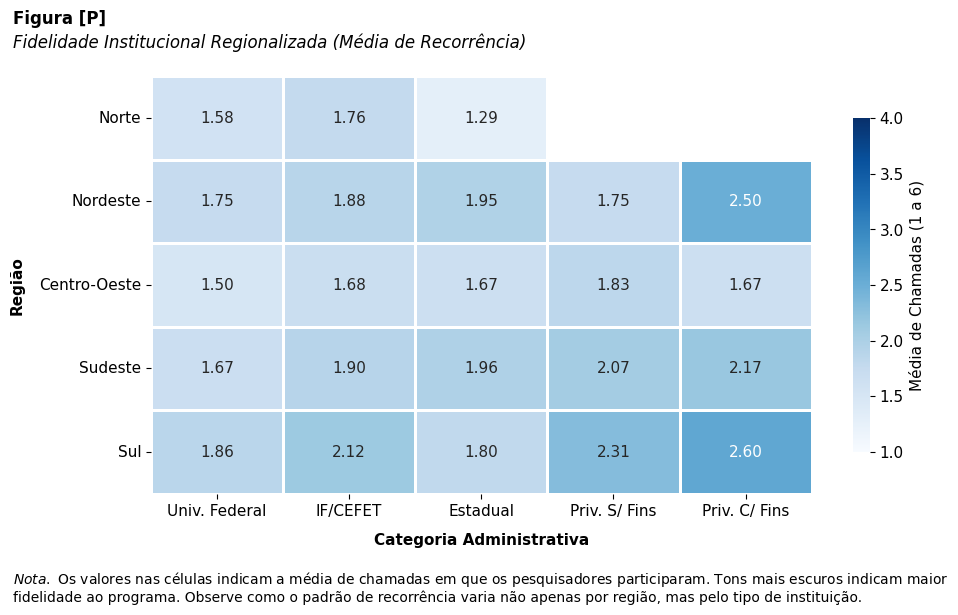

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

# ==============================================================================
# 1. CONFIGURAÇÃO ESTÉTICA (APA)
# ==============================================================================
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['font.size'] = 11
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.spines.left'] = False
rcParams['axes.spines.bottom'] = False
rcParams['legend.frameon'] = False

# ==============================================================================
# 2. PROCESSAMENTO DE DADOS
# ==============================================================================
arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"

try:
    df = pd.read_csv(arquivo, low_memory=False)

    # Filtros Básicos
    df = df.dropna(subset=['regiao_corrigida', 'num_chamadas_participou', 'categoria_adm_corrigida'])

    # Seleção das Categorias Principais (para evitar ruído com categorias raras)
    cats_foco = [
        'Universidade Federal',
        'IF/CEFET',
        'PUBLICA ESTADUAL',
        'PRIVADA SEM FINS LUCRATIVOS',
        'PRIVADA COM FINS LUCRATIVOS',
        'INSTITUTO DE PESQUISA'
    ]
    df = df[df['categoria_adm_corrigida'].isin(cats_foco)].copy()

    # Mapeamento para nomes curtos (Melhora a visualização)
    mapa_adm = {
        'Universidade Federal': 'Univ. Federal',
        'IF/CEFET': 'IF/CEFET',
        'PUBLICA ESTADUAL': 'Estadual',
        'PRIVADA SEM FINS LUCRATIVOS': 'Priv. S/ Fins',
        'PRIVADA COM FINS LUCRATIVOS': 'Priv. C/ Fins',
        'INSTITUTO DE PESQUISA': 'Inst. Pesquisa'
    }
    df['adm_short'] = df['categoria_adm_corrigida'].map(mapa_adm)

    # Mapeamento para Regiões (opcional, se quiser abreviar, mas nomes completos cabem)

    # PIVOT TABLE: Média de Chamadas (Fidelidade)
    # Rows: Região | Cols: Categoria
    heatmap_data = pd.pivot_table(
        df,
        values='num_chamadas_participou',
        index='regiao_corrigida',
        columns='adm_short',
        aggfunc='mean'
    )

    # Ordenação Lógica
    ordem_reg = ['Norte', 'Nordeste', 'Centro-Oeste', 'Sudeste', 'Sul']
    ordem_cols = ['Univ. Federal', 'IF/CEFET', 'Estadual', 'Priv. S/ Fins', 'Priv. C/ Fins']

    heatmap_data = heatmap_data.reindex(index=ordem_reg, columns=ordem_cols)

except Exception as e:
    print(f"Erro: {e}")
    # Mock data
    heatmap_data = pd.DataFrame(
        [[2.5, 1.8, 1.5, 1.2, 1.1], [2.8, 2.0, 1.6, 1.3, 1.2]],
        columns=['Univ. Federal', 'IF/CEFET', 'Estadual', 'Priv. S/ Fins', 'Priv. C/ Fins'],
        index=['Norte', 'Sudeste']
    )

# ==============================================================================
# 3. PLOTAGEM (HEATMAP DE MÉDIA)
# ==============================================================================
def plot_recurrence_heatmap():
    fig, ax = plt.subplots(figsize=(10, 6))

    # Heatmap com escala sequencial (Greens ou Blues)
    # vmin/vmax fixados para garantir que a escala de cor tenha sentido absoluto
    # (Ex: 1 = Pontual, 4 = Consolidado)
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        linewidths=1,
        linecolor='white',
        cbar_kws={'label': 'Média de Chamadas (1 a 6)', 'shrink': 0.8},
        vmin=1,
        vmax=4, # Teto visual para contraste (mesmo que haja valores maiores)
        ax=ax
    )

    # Ajustes de Eixos
    ax.set_xlabel("Categoria Administrativa", fontsize=11, weight='bold', labelpad=10)
    ax.set_ylabel("Região", fontsize=11, weight='bold', labelpad=10)
    plt.yticks(rotation=0)

    # Títulos e Nota
    fig.text(0.02, 0.98, "Figura [P]", fontsize=12, weight='bold')
    fig.text(0.02, 0.94, "Fidelidade Institucional Regionalizada (Média de Recorrência)", fontsize=12, style='italic')

    note = (r"$\it{Nota.}$ Os valores nas células indicam a média de chamadas em que os pesquisadores participaram. "
            "Tons mais escuros indicam maior fidelidade ao programa. Observe como o padrão de recorrência varia não apenas por região, mas pelo tipo de instituição.")
    fig.text(0.02, 0.02, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0.08, 1, 0.92])
    plt.savefig("heatmap_recorrencia_adm_reg.png", dpi=300, bbox_inches='tight')
    plt.show()

plot_recurrence_heatmap()